## === 逻辑回归原理 ===
逻辑回归不是回归，而是分类！

核心思想：

1. 线性回归输出连续值：z = w₁x₁ + ... + wₙxₙ + b

2. 通过Sigmoid函数将z映射到[0,1]区间：
   σ(z) = 1 / (1 + e^(-z))

3. 输出解释为属于正类的概率

4. 决策边界：通常以0.5为阈值进行分类

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                           classification_report, roc_curve, auc,
                           precision_recall_curve)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False



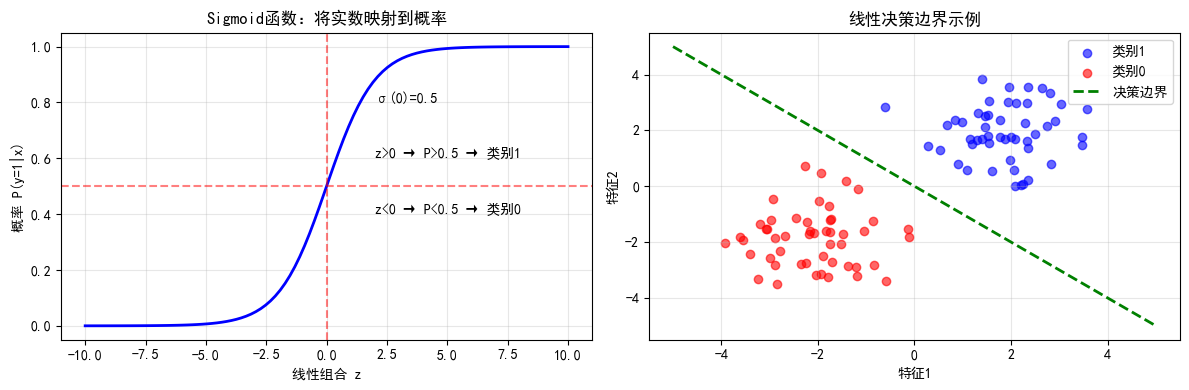

In [2]:
# 绘制Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
s = sigmoid(z)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(z, s, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('线性组合 z')
plt.ylabel('概率 P(y=1|x)')
plt.title('Sigmoid函数：将实数映射到概率')
plt.text(2, 0.8, f'σ(0)=0.5', fontsize=10)
plt.text(2, 0.6, f'z>0 → P>0.5 → 类别1', fontsize=10)
plt.text(2, 0.4, f'z<0 → P<0.5 → 类别0', fontsize=10)

plt.subplot(1, 2, 2)
# 决策边界示例
np.random.seed(42)
X1 = np.random.randn(50, 2) + [2, 2]
X0 = np.random.randn(50, 2) + [-2, -2]
plt.scatter(X1[:, 0], X1[:, 1], c='blue', label='类别1', alpha=0.6)
plt.scatter(X0[:, 0], X0[:, 1], c='red', label='类别0', alpha=0.6)

# 绘制决策边界
x_boundary = np.linspace(-5, 5, 100)
y_boundary = -x_boundary  # 简单的线性决策边界
plt.plot(x_boundary, y_boundary, 'g--', linewidth=2, label='决策边界')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('线性决策边界示例')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
#3 二分类问题 - 乳腺癌数据集

# 加载数据
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print("=== 乳腺癌数据集 ===")
print(f"样本数: {X.shape[0]}")
print(f"特征数: {X.shape[1]}")
print(f"特征名称: {cancer.feature_names}")
print(f"类别: 0(恶性) = {sum(y==0)}, 1(良性) = {sum(y==1)}")
print(f"\n数据集描述:\n{cancer.DESCR[:500]}...")

# 为了可视化，我们只取两个特征
X_vis = X[:, :2]  # 只取前两个特征：平均半径和平均纹理
feature_names_vis = cancer.feature_names[:2]

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_vis, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

=== 乳腺癌数据集 ===
样本数: 569
特征数: 30
特征名称: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
类别: 0(恶性) = 212, 1(良性) = 357

数据集描述:
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard d

In [4]:
#4 train

# 创建并训练模型
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 模型参数
print("\n=== 模型参数 ===")
print(f"系数: {lr_model.coef_[0]}")
print(f"截距: {lr_model.intercept_[0]}")

# 预测概率
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)

print(f"\n前5个样本的预测概率:")
for i in range(5):
    print(f"样本{i+1}: 恶性概率={y_pred_proba[i][0]:.3f}, "
          f"良性概率={y_pred_proba[i][1]:.3f}, "
          f"预测类别={y_pred[i]}, 实际类别={y_test[i]}")


=== 模型参数 ===
系数: [-3.28864282 -0.83044155]
截距: 0.6739346313989217

前5个样本的预测概率:
样本1: 恶性概率=0.998, 良性概率=0.002, 预测类别=0, 实际类别=0
样本2: 恶性概率=0.019, 良性概率=0.981, 预测类别=1, 实际类别=1
样本3: 恶性概率=0.521, 良性概率=0.479, 预测类别=0, 实际类别=0
样本4: 恶性概率=0.808, 良性概率=0.192, 预测类别=0, 实际类别=1
样本5: 恶性概率=0.999, 良性概率=0.001, 预测类别=0, 实际类别=0


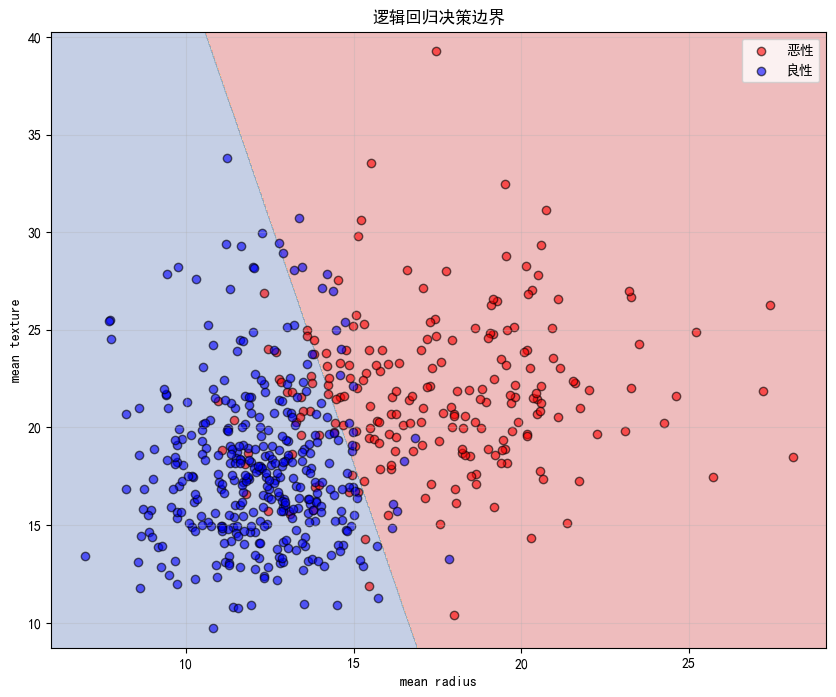

In [5]:
# 5 visualization

def plot_decision_boundary(X, y, model, scaler, feature_names):
    """绘制决策边界"""
    h = 0.02  # 网格步长
    
    # 创建网格
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测网格点
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    # 绘制
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # 绘制数据点
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], 
               c='red', label='恶性', alpha=0.6, edgecolors='black')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], 
               c='blue', label='良性', alpha=0.6, edgecolors='black')
    
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('逻辑回归决策边界')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(X_vis, y, lr_model, scaler, feature_names_vis)

=== 模型评估 ===
准确率: 0.8772

详细分类报告:
              precision    recall  f1-score   support

          恶性       0.83      0.83      0.83        42
          良性       0.90      0.90      0.90        72

    accuracy                           0.88       114
   macro avg       0.87      0.87      0.87       114
weighted avg       0.88      0.88      0.88       114



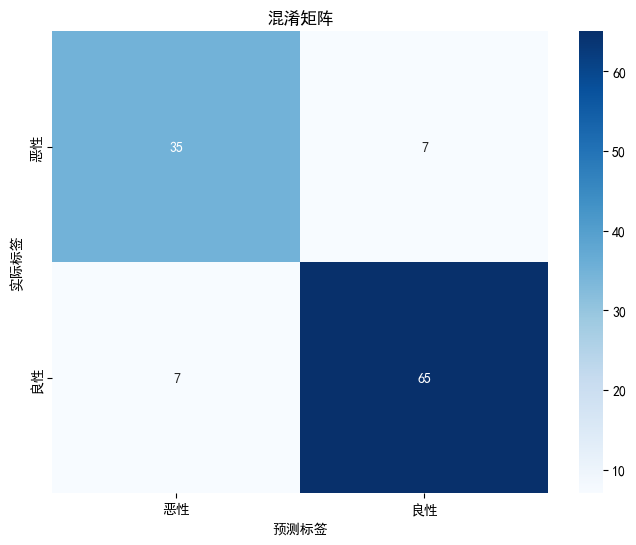


混淆矩阵解释:
真阴性(TN): 35 - 正确预测为恶性
假阳性(FP): 7 - 错误预测为良性
假阴性(FN): 7 - 错误预测为恶性
真阳性(TP): 65 - 正确预测为良性


In [6]:
# 6 evaluation

# 评估指标
print("=== 模型评估 ===")
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")

print("\n详细分类报告:")
print(classification_report(y_test, y_pred, 
                          target_names=['恶性', '良性']))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['恶性', '良性'],
            yticklabels=['恶性', '良性'])
plt.title('混淆矩阵')
plt.ylabel('实际标签')
plt.xlabel('预测标签')
plt.show()

# 解释混淆矩阵
print("\n混淆矩阵解释:")
print(f"真阴性(TN): {cm[0,0]} - 正确预测为恶性")
print(f"假阳性(FP): {cm[0,1]} - 错误预测为良性")
print(f"假阴性(FN): {cm[1,0]} - 错误预测为恶性")
print(f"真阳性(TP): {cm[1,1]} - 正确预测为良性")

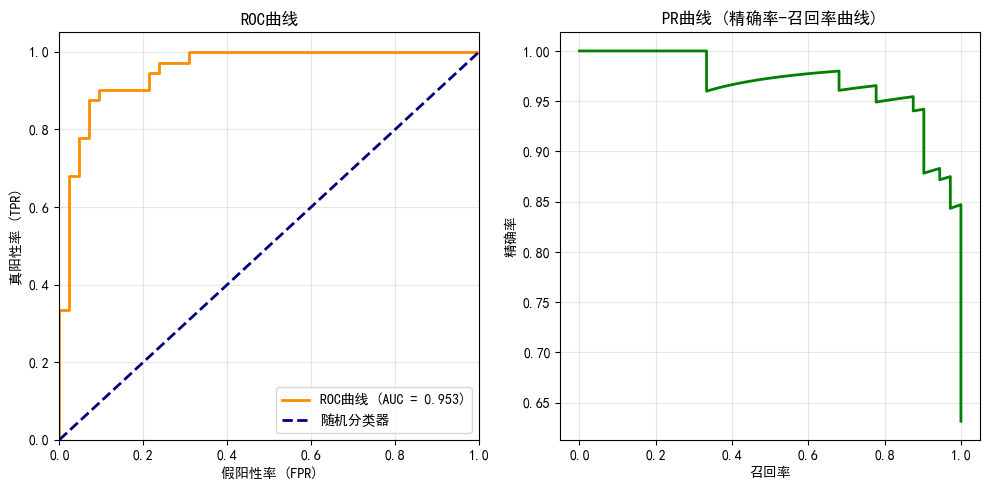


AUC值: 0.9534
AUC解释: 越接近1越好，0.5表示随机分类器


In [7]:
# 7 

# ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机分类器')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# PR曲线
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('召回率')
plt.ylabel('精确率')
plt.title('PR曲线 (精确率-召回率曲线)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAUC值: {roc_auc:.4f}")
print("AUC解释: 越接近1越好，0.5表示随机分类器")


=== 多分类问题: 鸢尾花分类 ===
样本数: 150
类别: ['setosa' 'versicolor' 'virginica']

模型准确率: 0.7333

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.62      0.50      0.56        10
   virginica       0.58      0.70      0.64        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30



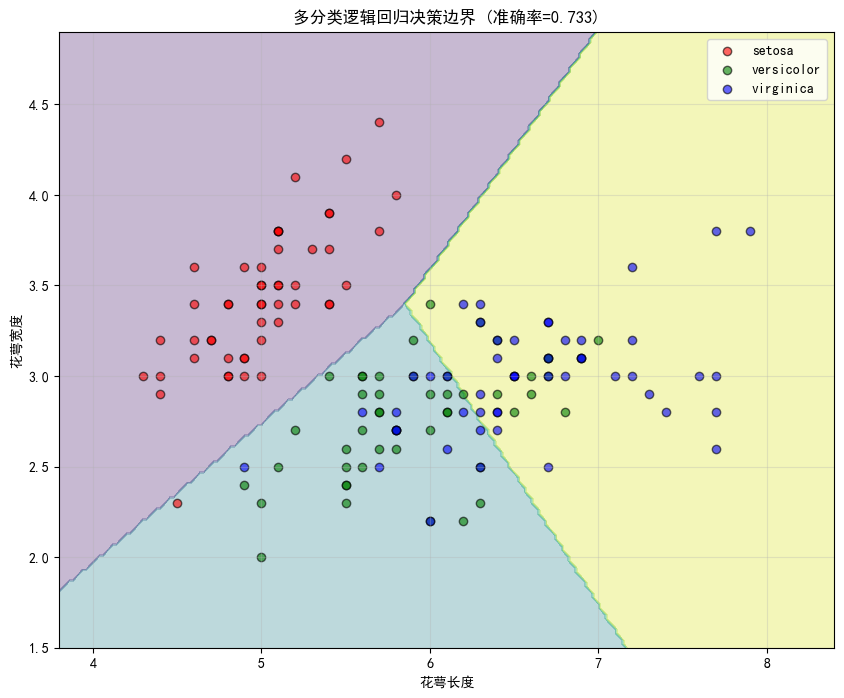

In [9]:
# 8 multi-cat

# 加载鸢尾花数据
iris = load_iris()
X_iris = iris.data[:, :2]  # 只取前两个特征便于可视化
y_iris = iris.target

print("\n=== 多分类问题: 鸢尾花分类 ===")
print(f"样本数: {X_iris.shape[0]}")
print(f"类别: {iris.target_names}")

# 划分数据
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# 标准化
scaler_iris = StandardScaler()
X_train_i_scaled = scaler_iris.fit_transform(X_train_i)
X_test_i_scaled = scaler_iris.transform(X_test_i)

# 训练多分类逻辑回归
# multi_class='ovr' 或 'multinomial'
lr_multi = LogisticRegression( max_iter=1000, random_state=42)
lr_multi.fit(X_train_i_scaled, y_train_i)

# 预测和评估
y_pred_i = lr_multi.predict(X_test_i_scaled)
accuracy = accuracy_score(y_test_i, y_pred_i)

print(f"\n模型准确率: {accuracy:.4f}")
print("\n分类报告:")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

# 多分类决策边界可视化
def plot_multiclass_boundary(X, y, model, scaler):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    colors = ['red', 'green', 'blue']
    for i, name in enumerate(iris.target_names):
        plt.scatter(X[y==i][:, 0], X[y==i][:, 1], 
                   c=colors[i], label=name, alpha=0.6, edgecolors='black')
    
    plt.xlabel('花萼长度')
    plt.ylabel('花萼宽度')
    plt.title(f'多分类逻辑回归决策边界 (准确率={accuracy:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_multiclass_boundary(X_iris, y_iris, lr_multi, scaler_iris)

i:\git\docs-public\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings


=== 超参数调优结果 ===
最佳参数: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
最佳交叉验证分数: 0.8967
测试集准确率: 0.8860


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


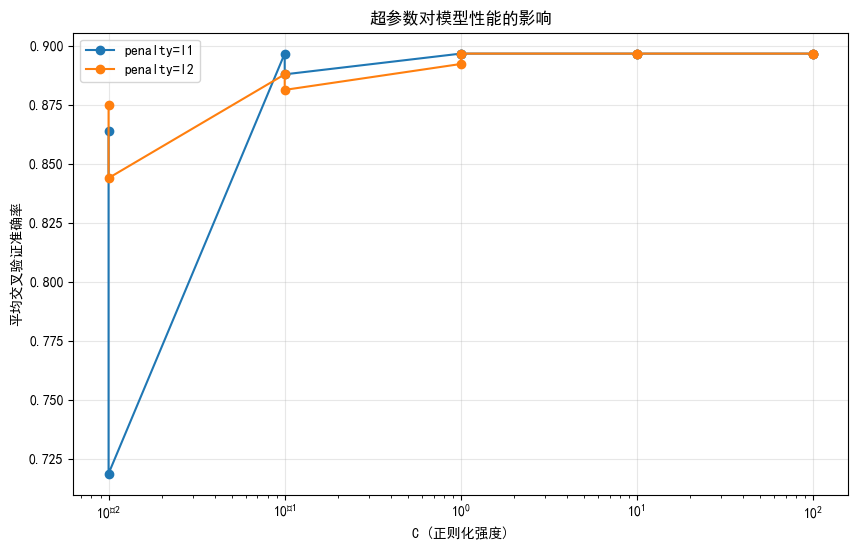

In [ ]:
# 9 交叉验证和超参数调优

from sklearn.model_selection import GridSearchCV

# 参数网格
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # 正则化强度的倒数
    'penalty': ['l1', 'l2'],  # 正则化类型
    'solver': ['liblinear', 'saga']  # 优化算法
}

# 网格搜索
lr_grid = LogisticRegression(max_iter=1000, random_state=42)
grid_search = GridSearchCV(lr_grid, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("\n=== 超参数调优结果 ===")
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")

# 使用最佳模型评估
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_scaled)
print(f"测试集准确率: {accuracy_score(y_test, y_pred_best):.4f}")

# 交叉验证结果可视化
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
for penalty in ['l1', 'l2']:
    mask = results['param_penalty'] == penalty
    subset = results[mask]
    plt.plot(subset['param_C'].astype(float), 
             subset['mean_test_score'], 
             marker='o', label=f'penalty={penalty}')

plt.xscale('log')
plt.xlabel('C (正则化强度)')
plt.ylabel('平均交叉验证准确率')
plt.title('超参数对模型性能的影响')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

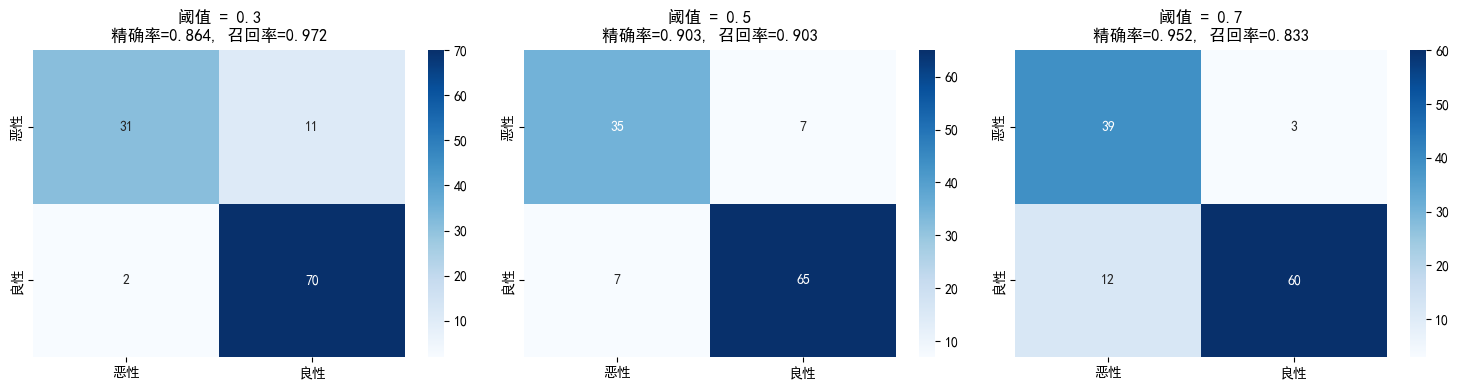


=== 实际应用建议 ===
1. 癌症筛查：降低阈值 → 提高召回率（不漏掉癌症患者）
2. 垃圾邮件：提高阈值 → 提高精确率（减少误判重要邮件）
3. 金融风控：平衡阈值 → 根据成本效益分析


In [11]:
# 10 practice

# 根据不同场景调整决策阈值
thresholds = [0.3, 0.5, 0.7]
probs = y_pred_proba[:, 1]

plt.figure(figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    y_pred_threshold = (probs >= threshold).astype(int)
    
    plt.subplot(1, 3, idx+1)
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    sns.heatmap(cm_threshold, annot=True, fmt='d', cmap='Blues',
                xticklabels=['恶性', '良性'],
                yticklabels=['恶性', '良性'])
    
    tn, fp, fn, tp = cm_threshold.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    plt.title(f'阈值 = {threshold}\n'
              f'精确率={precision:.3f}, 召回率={recall:.3f}')

plt.tight_layout()
plt.show()

print("\n=== 实际应用建议 ===")
print("1. 癌症筛查：降低阈值 → 提高召回率（不漏掉癌症患者）")
print("2. 垃圾邮件：提高阈值 → 提高精确率（减少误判重要邮件）")
print("3. 金融风控：平衡阈值 → 根据成本效益分析")

### 逻辑回归关键点

- ✅ 输出：概率值，不是类别标签
- ✅ 损失函数：对数损失（交叉熵损失）
- ✅ 决策边界：线性（只能解决线性可分问题）
- ✅ 优点：简单、快速、可解释性强
- ❌ 缺点：不能处理非线性问题、对异常值敏感

### 与线性回归对比

| 对比项 | 线性回归 | 逻辑回归 |
|--------|----------|----------|
| 预测目标 | 连续值 | 概率值 |
| 损失函数 | MSE | 交叉熵损失 |

### 何时使用逻辑回归

1. 二分类或多分类问题
2. 需要概率输出
3. 特征与目标存在线性关系
4. 模型可解释性要求高